In [1]:
module('load', 'pytorch/gpu-cuda-12.1/2.2.0')

Loading pytorch/gpu-cuda-12.1/2.2.0
  Loading requirement: cuda/12.1 cudnn/8.9.2


In [2]:
import numpy as np
from shared_utils import units
import astropy.units as u
from shared_utils import recursive_to_tensor
import torch
from deep_learning import ResNet50
from collections import OrderedDict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50(num_classes=2).to(device)
#ckpt = torch.load("../../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth", map_location=device)
#ckpt = torch.load("../../trained_classifiers/RUN1clusterEpochFFT/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-04_13-33-39.pth", map_location=device)
#ckpt = torch.load("BEST_checkpoint.pth", map_location=device) # good inteferometric

ckpt = torch.load("../trained_classifiers/FFTBigCatalogs2/3_min_mass_10e8_6_long/checkpoints/BEST_checkpoint.pth", map_location=device)


#ckpt = torch.load("../../trained_classifiers/RUN1clusterEpochFFT/3_min_mass_10e8_6/checkpoints/checkpoint_epoch_5_2025-08-04_12-42-32.pth", map_location=device)

state_dict = ckpt["model_state_dict"]
new_state = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")  # remove `module.` if present
    new_state[name] = v

# 4) load weights into your model (don’t reassign!)
missing, unexpected = model.load_state_dict(new_state, strict=False)
print("missing keys:", missing)
print("unexpected keys:", unexpected)
model.eval()

from abc import ABC, abstractmethod
class ImgLastProc(ABC):
    @abstractmethod
    def __call__(self, imgs : torch.Tensor)-> torch.Tensor:
        # here we have imgs bacause we are intedned to always work with batches at this stage
        pass
class Normalizer(ImgLastProc):
    def __call__(self, imgs : torch.Tensor)-> torch.Tensor:
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        imgs = imgs / max_val

        return imgs
    
class AstroNormalizer(ImgLastProc):
    def __call__(self, imgs):
    # Your data is naturally zero-centered, so only scale by std
        return imgs / 4.24e-17 
    
class NormalizerInterf(ImgLastProc):
    def __call__(self, imgs: torch.Tensor) -> torch.Tensor:
        # Find min and max across spatial dimensions
        min_val = imgs.amin(dim=(2, 3), keepdim=True)
        max_val = imgs.amax(dim=(2, 3), keepdim=True)

        # Shift and scale to [-1, 1]
        imgs = 2 * (imgs - min_val) / (max_val - min_val) - 1
        return imgs
    
    
from noise_applicator.noisers.base_noiser import EuclidNoiserInterfPSF, OnlyInterfPSF

normalizer = NormalizerInterf()
noiser= EuclidNoiserInterfPSF()

cpu
missing keys: []
unexpected keys: []
The PthPSF is loaded as it is. All the physical considerations must be done building it.


In [3]:
import torch

def fit_relu_mle_batch(x: torch.Tensor, Y: torch.Tensor):
    """
    x: (T,)        sorted abscissae
    Y: (T, H, W)   observations per pixel
    returns (A, M, B) each of shape (H, W)
    """
    T, H, W = Y.shape
    device = Y.device

    # 1) prefix sums of x and x^2
    ps_x  = torch.cat([torch.zeros(1, device=device), x.cumsum(0)], dim=0)     # (T+1)
    ps_x2 = torch.cat([torch.zeros(1, device=device), (x*x).cumsum(0)], dim=0) # (T+1)

    # 2) prefix sums of y, y^2, and x*y along dim=0
    Y2 = Y*Y
    XY = x.view(T,1,1) * Y

    ps_y  = torch.cat([torch.zeros(1,H,W,device=device), Y.cumsum(0)],  dim=0)  # (T+1,H,W)
    ps_y2 = torch.cat([torch.zeros(1,H,W,device=device), Y2.cumsum(0)], dim=0)
    ps_xy = torch.cat([torch.zeros(1,H,W,device=device), XY.cumsum(0)], dim=0)

    S_tot_y   = ps_y[-1]   # (H,W)
    S_Y2_tot  = ps_y2[-1]  # (H,W)

    # 3) build interval‐wise scalars (i = 0..T-2)
    i       = torch.arange(0, T-1, device=device)        # (T-1)
    N_less  = (i+1).view(-1,1,1)                         # (T-1,1,1)
    N_ge    = (T - (i+1)).view(-1,1,1)                   # (T-1,1,1)

    S_A_x   = (ps_x[-1]  - ps_x[i+1]).view(-1,1,1)       # (T-1,1,1)
    S_A_x2  = (ps_x2[-1] - ps_x2[i+1]).view(-1,1,1)

    S_A_y   = ps_y[-1].unsqueeze(0)  - ps_y[i+1]         # (T-1,H,W)
    S_A_xy  = ps_xy[-1].unsqueeze(0) - ps_xy[i+1]

    # 4) OLS slope m_i and intercept root‐for‐a
    denom   = N_ge*S_A_x2 - S_A_x**2
    m_i     = (N_ge*S_A_xy - S_A_x*S_A_y) / denom

    a_star  = (
        S_A_x
        - (T*S_A_y - N_ge*S_tot_y) / (m_i * N_less)
    ) / N_ge

    # 5) mask out any a_star outside its [x_i, x_{i+1}] interval
    x_i     = x[:-1].view(-1,1,1)
    x_ip1   = x[1:].view(-1,1,1)
    valid   = (a_star > x_i) & (a_star < x_ip1)

    # 6) corresponding b*
    b_star  = (S_tot_y/T) - (m_i/T)*(S_A_x - N_ge*a_star)

    # 7) assemble SSE in closed form:
    S_A_xy_shift = S_A_xy - a_star*S_A_y
    S_A_x_shift  = S_A_x  - N_ge*a_star
    S_A_shift2   = S_A_x2 - 2*a_star*S_A_x + N_ge*a_star*a_star

    SSE = (
        S_Y2_tot.unsqueeze(0)
        - 2*b_star*S_tot_y.unsqueeze(0)
        - 2*m_i*S_A_xy_shift
        + T*b_star*b_star
        + 2*b_star*m_i*S_A_x_shift
        + (m_i*m_i)*S_A_shift2
    )

    # 8) ignore invalid intervals
    SSE = torch.where(valid, SSE, torch.tensor(float('inf'), device=device))

    # 9) pick best i per pixel
    best_i = SSE.argmin(dim=0)        # (H,W)

    # 10) gather a, m, b at best_i
    grid_h, grid_w = torch.meshgrid(
        torch.arange(H, device=device),
        torch.arange(W, device=device),
        indexing='ij'
    )
    A = a_star[best_i,       grid_h, grid_w]
    M = m_i   [best_i,       grid_h, grid_w]
    B = b_star[best_i,       grid_h, grid_w]

    return A, M, B



In [4]:
import torch.nn.functional as F
from lensing_system import LensModel as LensModelNonBatched
from lensing_system_broadcasting import LensModel
from lensing_system_broadcasting import SourceModel

from noise_applicator import NoiseApplicator, GaussKernel
from shared_utils.physics_relations import r_max_moline
from deep_learning import DeflectionFieldDataset, custom_dataloader, NoNoiseDataset
import matplotlib.pyplot as plt
import tqdm
import torch
import math

sub_dict = {
    "type": "NFW",
    "is_substructure": True,
    "params": {
        "pos": [
            1.1963320503127761e-05,
            -7.479630767193157e-06
        ],
        "mass_max": 1.8308882432e10,      # 18308882432.0
        "r_max_kpc": 14.0805025100708,
        "redshift": float('inf')         # extracted as inf
    }
}



from shared_utils import _grid_lens
eval_grid=_grid_lens(8.0, 30, device="cuda")

class SensMapMaker:
    def __init__(
        self,
        substructure_dict=sub_dict,
        sub_key_changed="mass_max", # this is not really flexible, as we change the concentration accordingly
        catalog_name = "NOSUB_cat",
        values_key = 10**torch.linspace(8.0,11., 11),
        evaluation_grid=eval_grid,
        image_grid_npix = 80,
        image_grid_size = 8.0,
        upsampling =5,
        model=model,
        batch_size=512,
        sample_index = 0,
        noiser = noiser,
        normalizer = normalizer
    ):
        self.image_grid=_grid_lens(image_grid_size, image_grid_npix*upsampling, device="cuda")
        self.evaluation_grid=evaluation_grid
        self.batch_size=batch_size
        self.model=model.to("cuda")
        self.values_key = values_key
        self.noiser = noiser
        self.normalizer = normalizer
        self.upsampling = upsampling

        dataset = DeflectionFieldDataset(
            catalog_name = catalog_name,
            grid_width_arcsec=8.0,
            grid_pixel_side=80,
            upscaling=upsampling,
            broadcasting=True,
            samples_used='all'
        )
        deflection_batch, batch_data = dataset.get_batch([sample_index])

        # Extract the single sample from the batch
        base_deflection = deflection_batch[0]
        #self.source_redshift = main_lens_dict["source_model"]["params"]["redshift"]
        self.base_deflection = base_deflection.unsqueeze(0).repeat(batch_size, 1, 1, 1)
        #for the source data and precomputed data we need to do the same
        precomp = batch_data['precomputed_data']
        self.precomp = self.process_precomp_data(precomp, batch_size=batch_size)
        source_data = batch_data['source_data']
        self.source_data = self.process_source_data(source_data, batch_size=batch_size)

        self.sub_raw=substructure_dict
        self.set_sub_params_matrix(evaluation_grid, sub_key_changed, values_key)
        self.source_model=SourceModel(self.source_data, self.precomp)
        image=self.source_model(self.base_deflection)
        print(image.shape)
        
        print(image.shape)

            
        noiser.set_device("cuda")
        image=F.avg_pool2d(image, kernel_size=self.upsampling, stride=self.upsampling)
        noisy_image = self.noiser(image.unsqueeze(1))

        self.get_logits_matrix()


    def process_precomp_data(self, precomp, batch_size):
        #disassemble param tensor and indexes and repeat
        params = precomp['params'][0]
        
        precomp_processed = {
            'sys_idx':   torch.arange(0, batch_size, device="cuda"),
            'params': params.repeat(batch_size, 1), 
            'param_map': precomp['param_map']
        }

        return precomp_processed


    def process_source_data(self, source_data, batch_size):
        source_type=list(source_data.keys())[0]
        init_tensor = source_data[source_type]['params']
        source_init={
            source_type: 0
        }
        print(source_data)
        source_init[source_type] = {
            'sys_idx':   torch.arange(0, batch_size, device="cuda"),
            'params':    init_tensor.repeat(batch_size, 1),
#            'param_map': source_data['param_map']
        }
        return source_init
    

    def set_sub_params_matrix(self, evaluation_grid, sub_key_changed, values_key):
        # thi is a matrix of this shape:
        # if n_p is the number of params of the sub, and n_t the nubmer of values tried
        # [n_p, n_t, shape_eval_grid]
        H, W = evaluation_grid.shape[:2]

        self.n_values=n_values=torch.as_tensor(values_key).shape[0]
        sub_param_map={
            'NFW': ['pos_x', 'pos_y','mass_max','r_max_kpc','redshift'],
        }

        sub_type=self.sub_raw["type"]
        sub_params=self.sub_raw["params"]

        if sub_type not in sub_param_map:
            raise NotImplemented

        if sub_type=='NFW':
            init_tensor=torch.tensor([
                sub_params['pos'][0],
                sub_params['pos'][1],
                sub_params['mass_max'],
                sub_params['r_max_kpc'],
                sub_params['redshift'],

            ], device="cuda")
            
            self.n_params=5
            self.sub_type='NFW'
            params_matrix=torch.empty((self.n_params, n_values, evaluation_grid.shape[0], evaluation_grid.shape[1]))
            params_matrix[0, :, :, :]=evaluation_grid[:,:, 0]
            params_matrix[1, :, :, :]=evaluation_grid[:,:, 1]
            params_matrix[2:] = init_tensor[2:, None, None, None].expand(-1, n_values, H, W)
            #now_fill the rest of the matrix
            
            if sub_key_changed=="mass_max":
                # move to the same device/dtype as your params_matrix
                vals = torch.as_tensor(values_key, device=params_matrix.device, dtype=params_matrix.dtype)
                
                #value_r_max=torch.as_tensor((torch.zeros(values_key.shape)+1)*0.0007507442919336159, device=params_matrix.device, dtype=params_matrix.dtype)
                value_r_max=torch.as_tensor(r_max_moline(values_key), device=params_matrix.device, dtype=params_matrix.dtype)

                # reshape to (n_values, 1, 1)
                vals = vals.view(n_values, 1, 1)
                value_r_max= value_r_max.view(n_values, 1, 1)

                # Option B: explicitly expand to (n_values, H, W)
                vals_expanded = vals.expand(n_values, H, W)
                value_r_max_expanded=value_r_max.expand(n_values, H, W)
                params_matrix[2] = vals_expanded
                params_matrix[3] = value_r_max_expanded

            
            else:
                raise NotImplemented
                
            self.params_matrix=params_matrix


    def get_logits_matrix(self):
        
        #initialize the logits matrix
        all_logits=[]
        bs=self.batch_size
        flat = self.params_matrix.permute(1, 2, 3, 0)  
        flat = flat.reshape(-1, self.n_params)  
        shared_precomp=self.precomp
        #print("setting the model to train to check the screwed up batch norms") <- it does not work, this batch is made of super similar images!
        self.model.eval()
        H, W = self.evaluation_grid.shape[:2]
        tot_im_to_comp=flat.shape[0]
        
        #Noise
        self.noiser.set_device("cuda")

        #strategy with last batch:just pad and slice away
        with torch.no_grad():
            for i in tqdm.tqdm(range(0, flat.shape[0], bs)):
                is_last_batch=i+bs> tot_im_to_comp
                if is_last_batch:
                    batch_params = flat[i:i+bs]   
                    cur_bs = batch_params.size(0)
                    last_row = batch_params[-1:]
                    padding  = last_row.expand(bs - cur_bs, -1)
                    batch_params = torch.cat([batch_params, padding], dim=0)
                else:
                    batch_params = flat[i:i+bs]      
                    
                sub_init=self.get_sub_init(batch_params, self.sub_type)
                sub_model=LensModel(bs, sub_init, shared_precomp)

                sub_deflection = sub_model.deflection_field(self.image_grid)
                source_grid=self.base_deflection+sub_deflection
                no_noise_image_batch=self.source_model(source_grid).unsqueeze(1)
                no_noise_image_batch2=F.avg_pool2d(no_noise_image_batch, kernel_size=self.upsampling, stride=self.upsampling)

                images= self.noiser(no_noise_image_batch2)
                images= self.normalizer(images)

                logits = self.model(images).detach().cpu()         # -> [<=bs, 2]

                if is_last_batch:
                    all_logits.append(logits[:cur_bs])
                else:
                    all_logits.append(logits)


        all_logits = torch.cat(all_logits, dim=0)  # [n_values*H*W, 2]
        logits_matrix = all_logits.view(self.n_values, H, W, 2)
        self.logits_matrix = logits_matrix.permute(3, 0, 1, 2)
        
        
    def get_sub_init(self, parameters_batch, sub_type):
        sub_param_map={
            'NFW': ['pos_x', 'pos_y','mass_max','r_max_kpc','redshift'],
        }
        sub_init= {
            sub_type:{
                'sys_idx':   torch.arange(0, parameters_batch.shape[0], device="cuda"),
                'params':    parameters_batch,
                'param_map': sub_param_map[sub_type]
            }
        }
        return sub_init

    def get_sensitivity_map(self, threshold):
        probs=torch.softmax(self.logits_matrix, dim=0)
        R=torch.log10(probs[1]/probs[0])
        x = torch.tensor(torch.log10(self.values_key))
        Y = R
        A_hat, M_hat, B_hat = fit_relu_mle_batch(x, Y)  
        A = A_hat.cpu().numpy()   # shape (H, W)
        M = M_hat.cpu().numpy()
        B = B_hat.cpu().numpy()

        # compute the x at which f(x)=threshold
        def sigma_to_R10(z: float) -> float:
            Phi = 0.5*(1.0 + math.erf(z / math.sqrt(2.0)))
            Phi = min(max(Phi, 1e-12), 1-1e-12)  # avoid infs
            return math.log10(Phi / (1.0 - Phi))
            
        threshold_R = sigma_to_R10(threshold)
        # compute the x at which f(x)=threshold
        mass_thres = (threshold_R - B) / M + A  # shape (H, W)

        # build mask: only keep pixels with positive slope and intercept ≤ 1e12
        valid = (M > 0) & (mass_thres <= 11)

        # set invalid pixels to NaN
        mass_thres_masked = mass_thres.copy()
        mass_thres_masked[~valid] = np.nan
        mass_thres_masked = np.flipud(mass_thres_masked)
        print("mass_thres shape:", mass_thres_masked.shape)

        # plot

        
        return(mass_thres_masked)

    


In [5]:
import numpy as np
import torch
import os
from dataclasses import dataclass, asdict
from typing import Optional
from shared_utils import _arcsec_to_rad
from config import CATALOGS_DIR
import json
from enum import Enum
from dataclasses import dataclass,  asdict, field
import torch
from abc import ABC, abstractmethod
from typing import Union, Optional, List
import numpy as np

from shared_utils import units
from shared_utils import _arcsec_to_rad
from config import CATALOGS_DIR
import os
from deep_learning import NoNoiseDataset, custom_dataloader

from shared_utils.physics_relations import r_max_moline

import json

# Import your existing classes
from catalog_manager.make_system_dicts_new import (
    SamplingInputs, FullSysConfig, Precomp, LensParams, 
    PEMD_params, EXT_Shear_params, SubParams, Sub_NFW,
    SourceParams, Gauss_params, uniform_prior, 
    sample_redshift_comoving_volume, random_pos_in_circle,
    r_max_moline
)
from shared_utils import units
from astropy.cosmology import Planck18 as cosmo


def rotate_positions(positions, angle_rad, center):
    """
    Rotate positions around a center point by a given angle.
    
    Args:
        positions: array of shape (N, 2) with x, y coordinates
        angle_rad: rotation angle in radians
        center: center point (x, y) around which to rotate
    
    Returns:
        Rotated positions array of shape (N, 2)
    """
    # Translate to origin
    translated = positions - center
    
    # Rotation matrix
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    
    # Apply rotation
    rotated_x = translated[:, 0] * cos_a - translated[:, 1] * sin_a
    rotated_y = translated[:, 0] * sin_a + translated[:, 1] * cos_a
    
    # Translate back
    rotated = np.stack([rotated_x, rotated_y], axis=1) + center
    
    return rotated


def generate_custom_rotation_angles():
    """
    Generate custom rotation angles:
    - 0 degrees
    - 90 degrees
    - 6 equally distributed angles between 0 and 360 (excluding extremes)
    
    Returns:
        Array of rotation angles in radians
    """
    # Start with 0 and 90 degrees
    angles_deg = [0.0, 90.0]
    
    # Add 6 equally distributed angles between 0 and 360 (excluding extremes)
    # This means we divide the circle into 6+1=7 parts and take 6 internal points
    # The angles will be at approximately 51.4°, 102.9°, 154.3°, 205.7°, 257.1°, 308.6°
    equally_distributed = np.linspace(0, 360, 7, endpoint=False)[1:]
    angles_deg.extend(equally_distributed.tolist())
    
    # Convert to radians
    angles_rad = np.array(angles_deg) * np.pi / 180.0
    
    print(f"Rotation angles (degrees): {[f'{a:.1f}' for a in angles_deg]}")
    print(f"Total number of rotations: {len(angles_deg)}")
    
    return angles_rad, angles_deg


def generate_base_system(sampling_inputs):
    """
    Generate a single base lensing system that will be rotated.
    
    Returns:
        Dictionary containing all system parameters
    """
    # Set random seed for reproducibility
    np.random.seed(42)
    
    # Generate redshifts and geometric configuration
    z_lens = 0.5  # Fixed lens redshift
    z_source = 1.5  # Fixed source redshift
    
    # Compute angular diameter distances
    D_l = cosmo.angular_diameter_distance(z_lens).value
    D_s = cosmo.angular_diameter_distance(z_source).value
    D_ls = cosmo.angular_diameter_distance_z1z2(z_lens, z_source).value
    
    # Set velocity dispersion and compute Einstein radius
    vel_disp = 320.0  # km/s
    theta_E = 4 * np.pi * (vel_disp / units.c)**2 * D_ls / D_s
    
    # Main lens parameters (PEMD)
    lens_pos = np.array([0.0, 0.0])  # Center the lens at origin
    lens_slope = 1.0  # Isothermal
    lens_q = 0.6  # Ellipticity
    lens_orient = np.pi / 4  # Initial orientation (45 degrees)
    
    # External shear
    shear_strength = 0.05
    shear_angle = np.pi / 3  # Initial shear direction
    
    # Source parameters
    source_I = 5e-14  # Intensity
    source_std_kpc = 1.0  # Size in kpc
    source_q = 1  # Source ellipticity
    source_orient = np.pi / 6  # Initial source orientation
    source_pos = random_pos_in_circle(0.3, 1)[0] * theta_E + lens_pos  # Position at 0.3 theta_E
    
    # Substructure parameters
    n_subs = 0  # Number of subhalos
    sub_masses = 10**np.random.uniform(8, 10, n_subs)  # Mass range 10^8 to 10^10
    sub_r_max = r_max_moline(sub_masses)
    
    # Generate subhalo positions around the lens
    sub_angles = np.random.uniform(0, 2*np.pi, n_subs)
    sub_radii = np.random.uniform(0.5, 2.0, n_subs) * theta_E  # Between 0.5 and 2 theta_E
    sub_pos_x = sub_radii * np.cos(sub_angles) + lens_pos[0]
    sub_pos_y = sub_radii * np.sin(sub_angles) + lens_pos[1]
    sub_positions = np.stack([sub_pos_x, sub_pos_y], axis=1) if n_subs > 0 else np.empty((0, 2))
    
    return {
        'geometry': {
            'z_lens': z_lens,
            'z_source': z_source,
            'D_l': D_l,
            'D_s': D_s,
            'D_ls': D_ls,
            'theta_E': theta_E,
            'vel_disp': vel_disp
        },
        'lens': {
            'pos': lens_pos,
            'slope': lens_slope,
            'q': lens_q,
            'orient': lens_orient
        },
        'shear': {
            'strength': shear_strength,
            'angle': shear_angle
        },
        'source': {
            'pos': source_pos,
            'I': source_I,
            'std_kpc': source_std_kpc,
            'q': source_q,
            'orient': source_orient
        },
        'subs': {
            'n': n_subs,
            'masses': sub_masses,
            'r_max': sub_r_max,
            'positions': sub_positions
        }
    }


def create_rotated_system(base_system, rotation_angle):
    """
    Create a rotated version of the base system.
    
    Args:
        base_system: Dictionary containing base system parameters
        rotation_angle: Rotation angle in radians
    
    Returns:
        FullSysConfig object with rotated parameters
    """
    # Create FullSysConfig object
    full_sys_conf = FullSysConfig(
        precomp=Precomp(),
        lens_par=LensParams(),
        source_par=SourceParams(),
        sub_par=SubParams()
    )
    
    # Set geometry (doesn't change with rotation)
    full_sys_conf.precomp.D_l = np.array([base_system['geometry']['D_l']])
    full_sys_conf.precomp.D_s = np.array([base_system['geometry']['D_s']])
    full_sys_conf.precomp.D_ls = np.array([base_system['geometry']['D_ls']])
    full_sys_conf.precomp.theta_E = np.array([base_system['geometry']['theta_E']])
    
    # Create PEMD lens with rotated orientation
    lens_orient_rotated = base_system['lens']['orient'] + rotation_angle
    lens_orient_rotated = lens_orient_rotated % (2 * np.pi)  # Keep in [0, 2π]
    
    lens_params = PEMD_params(
        z=np.array([base_system['geometry']['z_lens']]),
        pos=np.array([base_system['lens']['pos']]),
        vel_disp=np.array([base_system['geometry']['vel_disp']]),
        slope=np.array([base_system['lens']['slope']]),
        orient=np.array([lens_orient_rotated]),
        q=np.array([base_system['lens']['q']])
    )
    full_sys_conf.lens_par = lens_params
    
    # Create external shear with rotated angle
    shear_angle_rotated = base_system['shear']['angle'] + rotation_angle
    shear_angle_rotated = shear_angle_rotated % (2 * np.pi)
    
    ext_shear = EXT_Shear_params(
        s=np.array([base_system['shear']['strength']]),
        d=np.array([shear_angle_rotated])
    )
    full_sys_conf.secondary_lens_par = [ext_shear]
    
    # Rotate source position around lens center
    source_pos_rotated = rotate_positions(
        np.array([base_system['source']['pos']]),
        rotation_angle,
        base_system['lens']['pos']
    )[0]
    
    # Create source with rotated orientation and position
    source_orient_rotated = base_system['source']['orient'] + rotation_angle
    source_orient_rotated = source_orient_rotated % (2 * np.pi)
    
    source_params = Gauss_params(
        z=np.array([base_system['geometry']['z_source']]),
        pos_abs=np.array([source_pos_rotated]),
        std_kpc=np.array([base_system['source']['std_kpc']]),
        I=np.array([base_system['source']['I']]),
        orient=np.array([source_orient_rotated]),
        q=np.array([base_system['source']['q']])
    )
    full_sys_conf.source_par = source_params
    
    # Rotate substructure positions around lens center
    if base_system['subs']['n'] > 0:
        sub_pos_rotated = rotate_positions(
            base_system['subs']['positions'],
            rotation_angle,
            base_system['lens']['pos']
        )
        
        # Create substructure parameters
        sub_params = Sub_NFW(
            pos_abs=sub_pos_rotated,
            belonging_index=np.zeros(base_system['subs']['n'], dtype=int),
            M_max=base_system['subs']['masses'],
            r_max=base_system['subs']['r_max']
        )
        full_sys_conf.sub_par = sub_params
    
    return full_sys_conf


def generate_rotation_catalog(
    catalog_name='rotation_catalog_custom',
    sampling_inputs=None
):
    """
    Generate a catalog with custom rotation angles of the same lensing system.
    Angles: 0°, 90°, and 6 equally distributed between 0 and 360 (excluding extremes)
    
    Args:
        catalog_name: Name for the output catalog
        sampling_inputs: SamplingInputs object with priors (optional)
    
    Returns:
        Dictionary containing all rotated systems
    """
    
    # Create default sampling inputs if not provided
    if sampling_inputs is None:
        sampling_inputs = SamplingInputs(
            prior_lens_orient=[0, 2. * np.pi],
            prior_lens_pos=[-1.0, 1.0],  # arcsec
            prior_lens_q=[0.2, 1.0],
            prior_lens_slope_normal=[1.0, 0.1],
            prior_sub_max_n=5,
            prior_sub_pos=[-3.0, 3.0],  # arcsec
            prior_sub_log_mass=[8., 10.],
            prior_source_I=1e-16,
            prior_source_std_main=2.0,  # kpc
            prior_source_frac_of_theta_pos=0.3,
            prior_source_orient=[0, 2. * np.pi],
            prior_source_q=[0.5, 1.0],
            prior_shear_d=[0., np.pi],
            prior_shear_s=[0., 0.1]
        )
    
    # Generate base system
    print("Generating base lensing system...")
    base_system = generate_base_system(sampling_inputs)
    
    # Generate custom rotation angles
    rotation_angles_rad, rotation_angles_deg = generate_custom_rotation_angles()
    n_rotations = len(rotation_angles_rad)
    
    # Lists to store all parameters for concatenation
    all_precomp_D_l = []
    all_precomp_D_s = []
    all_precomp_D_ls = []
    all_precomp_theta_E = []
    
    all_lens_params = []
    all_source_params = []
    all_sub_params = []
    all_shear_params = []
    
    # Generate rotated systems
    print(f"\nGenerating {n_rotations} rotated versions...")
    for i, (angle_rad, angle_deg) in enumerate(zip(rotation_angles_rad, rotation_angles_deg)):
        print(f"  Rotation {i+1}/{n_rotations}: {angle_deg:.1f} degrees")
        
        rotated_sys = create_rotated_system(base_system, angle_rad)
        
        # Collect precomputed values
        all_precomp_D_l.append(rotated_sys.precomp.D_l[0])
        all_precomp_D_s.append(rotated_sys.precomp.D_s[0])
        all_precomp_D_ls.append(rotated_sys.precomp.D_ls[0])
        all_precomp_theta_E.append(rotated_sys.precomp.theta_E[0])
        
        # Collect lens parameters
        all_lens_params.append({
            'pos': rotated_sys.lens_par.pos[0],
            'z': rotated_sys.lens_par.z[0],
            'vel_disp': rotated_sys.lens_par.vel_disp[0],
            'slope': rotated_sys.lens_par.slope[0],
            'orient': rotated_sys.lens_par.orient[0],
            'q': rotated_sys.lens_par.q[0]
        })
        
        # Collect source parameters
        all_source_params.append({
            'pos': rotated_sys.source_par.pos_abs[0],
            'z': rotated_sys.source_par.z[0],
            'I': rotated_sys.source_par.I[0],
            'std_kpc': rotated_sys.source_par.std_kpc[0],
            'orient': rotated_sys.source_par.orient[0],
            'q': rotated_sys.source_par.q[0]
        })
        
        # Collect substructure parameters
        if base_system['subs']['n'] > 0:
            all_sub_params.append({
                'positions': rotated_sys.sub_par.pos_abs,
                'masses': rotated_sys.sub_par.M_max,
                'r_max': rotated_sys.sub_par.r_max,
                'belonging_index': np.full(base_system['subs']['n'], i)
            })
        
        # Collect shear parameters
        all_shear_params.append({
            's': rotated_sys.secondary_lens_par[0].s[0],
            'd': rotated_sys.secondary_lens_par[0].d[0]
        })
    
    # Create combined catalog with all rotations
    print("\nCreating combined catalog...")
    combined_config = create_combined_catalog(
        all_precomp_D_l, all_precomp_D_s, all_precomp_D_ls, all_precomp_theta_E,
        all_lens_params, all_source_params, all_sub_params, all_shear_params,
        n_rotations, base_system['subs']['n']
    )
    
    # Save catalog
    cat_path = os.path.join(CATALOGS_DIR, f"{catalog_name}.pth")
    torch.save(combined_config, cat_path)
    print(f"Rotation catalog saved to {cat_path}")
    
    # Save metadata
    metadata = {
        'catalog_name': catalog_name,
        'n_rotations': n_rotations,
        'rotation_angles_deg': rotation_angles_deg,
        'rotation_description': 'Custom angles: 0°, 90°, then 51.4°, 102.9°, 154.3°, 205.7°, 257.1°, 308.6°',
        'base_system': {
            'n_subhalos': base_system['subs']['n'],
            'lens_q': base_system['lens']['q'],
            'source_q': base_system['source']['q'],
            'shear_strength': base_system['shear']['strength']
        }
    }
    
    metadata_path = os.path.join(CATALOGS_DIR, "sampling_configs", f"{catalog_name}_metadata.json")
    os.makedirs(os.path.dirname(metadata_path), exist_ok=True)
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata saved to {metadata_path}")
    
    return combined_config


def create_combined_catalog(
    all_precomp_D_l, all_precomp_D_s, all_precomp_D_ls, all_precomp_theta_E,
    all_lens_params, all_source_params, all_sub_params, all_shear_params,
    n_systems, n_subs_per_system
):
    """
    Create a combined catalog dictionary compatible with the lensing system broadcasting.
    """
    
    # Combine precomputed values
    precomp_dict = {
        "precomputed": {
            "params": torch.stack([
                torch.tensor(all_precomp_D_l, dtype=torch.float32),
                torch.tensor(all_precomp_D_s, dtype=torch.float32),
                torch.tensor(all_precomp_D_ls, dtype=torch.float32),
                torch.tensor(all_precomp_theta_E, dtype=torch.float32)
            ], dim=1),
            "param_map": ['D_l', 'D_s', 'D_ls', 'Theta_E'],
            "sys_idx": torch.arange(n_systems)
        }
    }
    
    # Combine PEMD lens parameters
    lens_pos_x = torch.tensor([p['pos'][0] for p in all_lens_params], dtype=torch.float32)
    lens_pos_y = torch.tensor([p['pos'][1] for p in all_lens_params], dtype=torch.float32)
    lens_z = torch.tensor([p['z'] for p in all_lens_params], dtype=torch.float32)
    lens_vel_disp = torch.tensor([p['vel_disp'] for p in all_lens_params], dtype=torch.float32)
    lens_slope = torch.tensor([p['slope'] for p in all_lens_params], dtype=torch.float32)
    lens_orient = torch.tensor([p['orient'] for p in all_lens_params], dtype=torch.float32)
    lens_q = torch.tensor([p['q'] for p in all_lens_params], dtype=torch.float32)
    
    pemd_dict = {
        "PEMD": {
            "params": torch.stack([lens_pos_x, lens_pos_y, lens_z, lens_vel_disp, 
                                  lens_slope, lens_orient, lens_q], dim=1),
            "param_map": ['pos_x', 'pos_y', 'redshift', 'vel_disp', 'slope', 'orient', 'q'],
            "sys_idx": torch.arange(n_systems)
        }
    }
    
    # Combine external shear parameters
    shear_s = torch.tensor([p['s'] for p in all_shear_params], dtype=torch.float32)
    shear_d = torch.tensor([p['d'] for p in all_shear_params], dtype=torch.float32)
    
    shear_dict = {
        "ExternalPotential": {
            "params": torch.stack([torch.zeros_like(shear_s), torch.zeros_like(shear_s), 
                                  shear_s, shear_d], dim=1),
            "param_map": ['shear_x', 'shear_y', 'shear_strength', 'shear_angle_rad'],
            "sys_idx": torch.arange(n_systems)
        }
    }
    
    # Combine substructure parameters if present
    masses_dict = {"mass_components": {**pemd_dict, **shear_dict}}
    
    if n_subs_per_system > 0 and all_sub_params:
        all_sub_pos = np.vstack([p['positions'] for p in all_sub_params])
        all_sub_masses = np.concatenate([p['masses'] for p in all_sub_params])
        all_sub_r_max = np.concatenate([p['r_max'] for p in all_sub_params])
        all_sub_belonging = np.concatenate([p['belonging_index'] for p in all_sub_params])
        
        nfw_dict = {
            "NFW": {
                "params": torch.stack([
                    torch.tensor(all_sub_pos[:, 0], dtype=torch.float32),
                    torch.tensor(all_sub_pos[:, 1], dtype=torch.float32),
                    torch.tensor(all_sub_masses, dtype=torch.float32),
                    torch.tensor(all_sub_r_max, dtype=torch.float32),
                    torch.full((len(all_sub_masses),), float('inf'), dtype=torch.float32)
                ], dim=1),
                "param_map": ['pos_x', 'pos_y', 'mass_max', 'r_max_kpc', 'redshift'],
                "sys_idx": torch.tensor(all_sub_belonging, dtype=torch.long)
            }
        }
        masses_dict["mass_components"]["NFW"] = nfw_dict["NFW"]
    
    # Combine source parameters
    source_pos_x = torch.tensor([p['pos'][0] for p in all_source_params], dtype=torch.float32)
    source_pos_y = torch.tensor([p['pos'][1] for p in all_source_params], dtype=torch.float32)
    source_I = torch.tensor([p['I'] for p in all_source_params], dtype=torch.float32)
    source_orient = torch.tensor([p['orient'] for p in all_source_params], dtype=torch.float32)
    source_q = torch.tensor([p['q'] for p in all_source_params], dtype=torch.float32)
    source_std = torch.tensor([p['std_kpc'] for p in all_source_params], dtype=torch.float32)
    source_z = torch.tensor([p['z'] for p in all_source_params], dtype=torch.float32)
    
    source_dict = {
        "source_models": {
            "Gaussian_blob": {
                "params": torch.stack([source_pos_x, source_pos_y, source_I, 
                                      source_orient, source_q, source_std, source_z], dim=1),
                "param_map": ['position_rad_x', 'position_rad_y', 'I', 'orient_rad', 
                             'q', 'std_kpc', 'redshift'],
                "sys_idx": torch.arange(n_systems)
            }
        }
    }
    
    # Create labels (all systems have substructure in this case)
    labels_dict = {
        'labels': {
            "sys_idx": torch.arange(n_systems),
            "label_values": torch.ones(n_systems, dtype=torch.long) if n_subs_per_system > 0 else torch.zeros(n_systems, dtype=torch.long)
        }
    }
    
    # Combine all dictionaries
    complete_dict = {
        **precomp_dict,
        **masses_dict,
        **source_dict,
        **labels_dict
    }
    
    return complete_dict


# Main execution
if __name__ == "__main__":
    # Generate the rotation catalog with custom angles
    catalog = generate_rotation_catalog(
        catalog_name='rotation_catalog_custom'
    )
    
    print("\nCatalog generation complete!")
    print("The catalog contains 8 rotations at angles:")
    print("  0°, 90°, 51.4°, 102.9°, 154.3°, 205.7°, 257.1°, 308.6°")
    print("\nYou can now use this catalog with NoNoiseDataset:")
    print("  dataset = NoNoiseDataset(")
    print("      catalog_name='rotation_catalog_custom',")
    print("      grid_pixel_side=100,")
    print("      grid_width_arcsec=6.0,")
    print("      broadcasting=True")
    print("  )")

Generating base lensing system...
Rotation angles (degrees): ['0.0', '90.0', '51.4', '102.9', '154.3', '205.7', '257.1', '308.6']
Total number of rotations: 8

Generating 8 rotated versions...
  Rotation 1/8: 0.0 degrees
  Rotation 2/8: 90.0 degrees
  Rotation 3/8: 51.4 degrees
  Rotation 4/8: 102.9 degrees
  Rotation 5/8: 154.3 degrees
  Rotation 6/8: 205.7 degrees
  Rotation 7/8: 257.1 degrees
  Rotation 8/8: 308.6 degrees

Creating combined catalog...
Rotation catalog saved to /raven/u/fcitterio/master_thesis_code/catalogs/rotation_catalog_custom.pth
Metadata saved to /raven/u/fcitterio/master_thesis_code/catalogs/sampling_configs/rotation_catalog_custom_metadata.json

Catalog generation complete!
The catalog contains 8 rotations at angles:
  0°, 90°, 51.4°, 102.9°, 154.3°, 205.7°, 257.1°, 308.6°

You can now use this catalog with NoNoiseDataset:
  dataset = NoNoiseDataset(
      catalog_name='rotation_catalog_custom',
      grid_pixel_side=100,
      grid_width_arcsec=6.0,
      br

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import OrderedDict

# your env:
from deep_learning import ResNet50
from deep_learning.NN_datasets import NoNoiseDataset
from noise_applicator.noisers.base_noiser import OnlyInterfPSF, EuclidNoiserInterfPSF
from shared_utils import _grid_lens
# assumed available in your codebase:
# from deep_learning.normalizers import NormalizerInterf
# from your_module import SensMapMaker

def load_model_weights(model, checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["model_state_dict"]
    new_state = OrderedDict((k.replace("module.", ""), v) for k, v in state_dict.items())
    model.load_state_dict(new_state, strict=False)
    return model

def create_interf_rotation_panel_all_catalog(
    catalog_name,
    rotations_deg,                         # used only for labeling
    sigma=3.0,
    grid_width_arcsec=8.0,
    grid_pixel_side=80,
    upscaling=5,
    interferometric_checkpoint="sensitivity_maps/BEST_checkpoint.pth",
    mass_log_min=8.0, mass_log_max=11.0, mass_log_steps=11,
    contour_perc=(50, 70, 85, 95),
    batch_size=256,
    title_prefix="Interferometric Rotation Sensitivity",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Dataset: use ALL entries (each one is a rotation)
    ds = NoNoiseDataset(
        catalog_name,
        grid_pixel_side=grid_pixel_side,
        grid_width_arcsec=grid_width_arcsec,
        broadcasting=True,
        samples_used="all",       # <-- per your setup
        upscaling=upscaling,
    )
    R = len(ds)
    if len(rotations_deg) != R:
        print(f"[warn] angles provided: {len(rotations_deg)}; catalog entries: {R}. "
              f"Titles will use min(R, len(angles)).")

    # Interferometric model once
    model = ResNet50(num_classes=2).to(device)
    load_model_weights(model, interferometric_checkpoint, device)
    model.eval()
    noiser = EuclidNoiserInterfPSF()
    normalizer = NormalizerInterf()  # assumed available

    # Sensitivity setup
    eval_grid = _grid_lens(grid_width_arcsec, 80, device=device)
    values_key = 10 ** torch.linspace(mass_log_min, mass_log_max, mass_log_steps)

    sub_dict = {
        "type": "NFW",
        "is_substructure": True,
        "params": {
            "pos": [1.1963320503127761e-05, -7.479630767193157e-06],
            "mass_max": 1.8308882432e10,
            "r_max_kpc": 14.0805025100708,
            "redshift": float('inf'),
        },
    }

    # Figure: 2 rows × (R columns + 1 colorbar)

    fig = plt.figure(figsize=(20, 5.0))
    gs = GridSpec(2, R + 1, figure=fig, hspace=0.05, wspace=0.02, width_ratios=[1]*R + [0.05])
    last_im = None

    for j in range(R):
        # Title angle (if fewer angles than entries, fall back to index)
        ang_lab = f"{rotations_deg[j]:.1f}°" if j < len(rotations_deg) else f"rot {j}"

        # Clean image for this rotation
        img, _ = ds.get_batch([j])
        img = img.to(device)

        # Contour levels from clean image
        no_noise_img = img[0, 0].detach().cpu().numpy()
        cont_levels = (np.percentile(no_noise_img[no_noise_img > 0], contour_perc)
                       if np.any(no_noise_img > 0) else None)

        # Top row: interferometric noisy image
        interf_img = noiser(img)
        ax_top = fig.add_subplot(gs[0, j])
        ax_top.imshow(interf_img[0, 0].detach().cpu().numpy(), cmap='viridis', origin='lower')
        ax_top.set_xticks([]); ax_top.set_yticks([])
        ax_top.set_title(ang_lab, fontsize=12, fontweight='bold')
        if j == 0:
            ax_top.set_ylabel("Interferometric", fontsize=12, fontweight='bold')

        # Bottom row: sensitivity at sigma
        sens_maker = SensMapMaker(
            substructure_dict=sub_dict,
            sub_key_changed="mass_max",
            catalog_name=catalog_name,
            values_key=values_key,
            evaluation_grid=eval_grid,
            image_grid_npix=grid_pixel_side,
            image_grid_size=grid_width_arcsec,
            upsampling=upscaling,
            model=model,
            batch_size=batch_size,
            sample_index=j,        # <-- just the j-th catalog entry
            noiser=noiser,
            normalizer=normalizer
        )
        mass_thres = np.flipud(sens_maker.get_sensitivity_map(sigma))

        ax_bot = fig.add_subplot(gs[1, j])
        last_im = ax_bot.imshow(mass_thres, cmap='plasma', origin='lower',
                                vmin=mass_log_min, vmax=mass_log_max)

        # Overlay contours from the clean image
        if cont_levels is not None:
            hs, ws = mass_thres.shape
            ho, wo = no_noise_img.shape
            x_cont = np.linspace(0, ws - 1, wo)
            y_cont = np.linspace(0, hs - 1, ho)
            ax_bot.contour(x_cont, y_cont, no_noise_img, levels=cont_levels,
                           colors='black', linewidths=0.5, alpha=0.6)

        ax_bot.set_xticks([]); ax_bot.set_yticks([])
        if j == 0:
            ax_bot.set_ylabel(f"Sensitivity (σ={sigma:.1f})", fontsize=12, fontweight='bold')

    # Shared colorbar
    cax = fig.add_subplot(gs[:, -1])
    cb = plt.colorbar(last_im, cax=cax)
    cb.set_label(r'$\log_{10} M_{\mathrm{thresh}}$', fontsize=15)
    cb.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    return fig

# ---- example run ----
if __name__ == "__main__":
    rotations = list(map(float, ['0.0', '90.0', '51.4', '102.9', '154.3', '205.7', '257.1', '308.6']))

    fig = create_interf_rotation_panel_all_catalog(
        catalog_name="rotation_catalog_custom",    # <-- your actual catalog name
        rotations_deg=rotations,
        sigma=3.0,
        interferometric_checkpoint="sensitivity_maps/BEST_checkpoint.pth"
    )
    fig.savefig("interf_rotation_sensitivity_panel.png", dpi=150, bbox_inches='tight')
    plt.show()


Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
tensor(8)
The PthPSF is loaded as it is. All the physical considerations must be done building it.
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[4.6018e-07, 1.2710e-06, 5.0000e-14, 5.2360e-01, 1.0000e+00, 1.0000e+00,
         1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.


100%|██████████| 275/275 [00:10<00:00, 25.96it/s]
/tmp/ipykernel_29258/824257282.py:251: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(torch.log10(self.values_key))


mass_thres shape: (80, 80)
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[-1.2710e-06,  4.6018e-07,  5.0000e-14,  2.0944e+00,  1.0000e+00,
          1.0000e+00,  1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.


100%|██████████| 275/275 [00:10<00:00, 26.01it/s]


mass_thres shape: (80, 80)
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[-7.0682e-07,  1.1523e-06,  5.0000e-14,  1.4212e+00,  1.0000e+00,
          1.0000e+00,  1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.


...

100%|██████████| 275/275 [00:10<00:00, 26.03it/s]


mass_thres shape: (80, 80)
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[ 1.1368e-06, -7.3147e-07,  5.0000e-14,  5.0116e+00,  1.0000e+00,
          1.0000e+00,  1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.


100%|██████████| 275/275 [00:10<00:00, 25.97it/s]


mass_thres shape: (80, 80)
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[1.2807e-06, 4.3270e-07, 5.0000e-14, 5.9092e+00, 1.0000e+00, 1.0000e+00,
         1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])
The PthPSF is loaded as it is. All the physical considerations must be done building it.
The PthPSF is loaded as it is. All the physical considerations must be done building it.


 96%|█████████▌| 264/275 [00:10<00:00, 25.97it/s]

Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
tensor(8)
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[4.6018e-07, 1.2710e-06, 5.0000e-14, 5.2360e-01, 1.0000e+00, 1.0000e+00,
         1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])


100%|██████████| 275/275 [00:10<00:00, 26.73it/s]
/tmp/ipykernel_29258/824257282.py:251: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(torch.log10(self.values_key))


mass_thres shape: (80, 80)
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[-1.2710e-06,  4.6018e-07,  5.0000e-14,  2.0944e+00,  1.0000e+00,
          1.0000e+00,  1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])


100%|██████████| 275/275 [00:10<00:00, 26.72it/s]


mass_thres shape: (80, 80)
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[-7.0682e-07,  1.1523e-06,  5.0000e-14,  1.4212e+00,  1.0000e+00,
          1.0000e+00,  1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])


...

mass_thres shape: (80, 80)
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[ 1.1368e-06, -7.3147e-07,  5.0000e-14,  5.0116e+00,  1.0000e+00,
          1.0000e+00,  1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])


100%|██████████| 275/275 [00:10<00:00, 26.71it/s]


mass_thres shape: (80, 80)
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[1.2807e-06, 4.3270e-07, 5.0000e-14, 5.9092e+00, 1.0000e+00, 1.0000e+00,
         1.5000e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([256, 400, 400])
torch.Size([256, 400, 400])


100%|██████████| 275/275 [00:10<00:00, 26.71it/s]
/tmp/ipykernel_29258/4091975476.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


mass_thres shape: (80, 80)


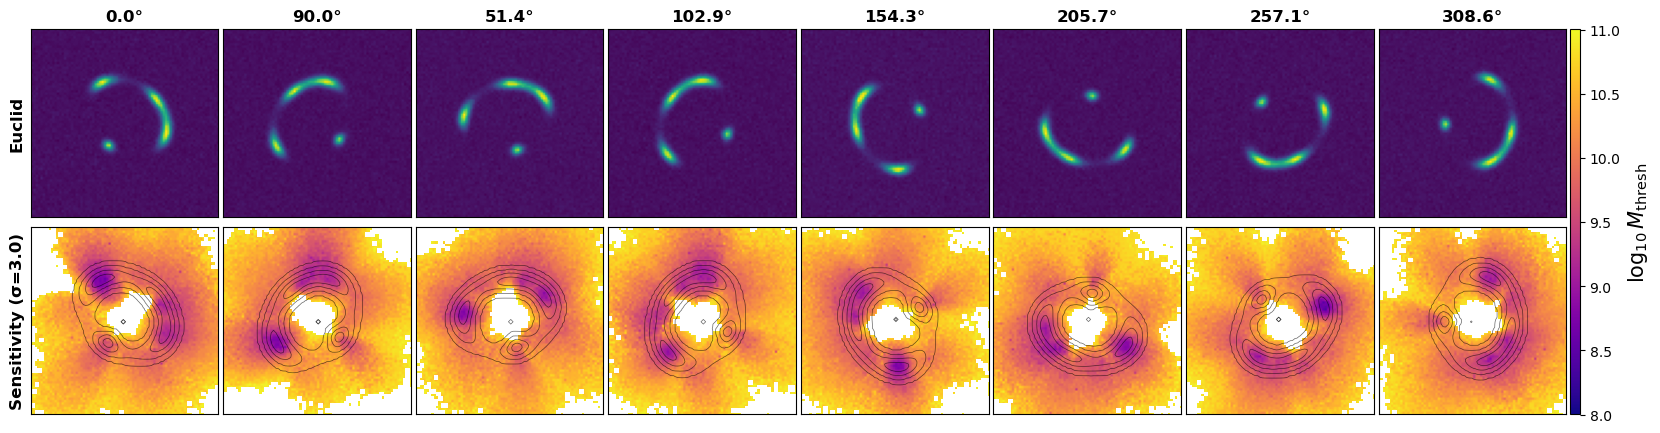

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import OrderedDict

# your env:
from deep_learning import ResNet50
from deep_learning.NN_datasets import NoNoiseDataset
from noise_applicator.noisers.base_noiser import OnlyInterfPSF, EuclidNoiserInterfPSF, EuclidNoiser
from shared_utils import _grid_lens
# assumed available in your codebase:
# from deep_learning.normalizers import NormalizerInterf
# from your_module import SensMapMaker

def load_model_weights(model, checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["model_state_dict"]
    new_state = OrderedDict((k.replace("module.", ""), v) for k, v in state_dict.items())
    model.load_state_dict(new_state, strict=False)
    return model

def create_interf_rotation_panel_all_catalog(
    catalog_name,
    rotations_deg,                         # used only for labeling
    sigma=3.0,
    grid_width_arcsec=8.0,
    grid_pixel_side=80,
    upscaling=5,
    interferometric_checkpoint="sensitivity_maps/BEST_checkpoint.pth",
    mass_log_min=8.0, mass_log_max=11.0, mass_log_steps=11,
    contour_perc=(50, 70, 85, 95),
    batch_size=256,
    title_prefix="Interferometric Rotation Sensitivity",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Dataset: use ALL entries (each one is a rotation)
    ds = NoNoiseDataset(
        catalog_name,
        grid_pixel_side=grid_pixel_side,
        grid_width_arcsec=grid_width_arcsec,
        broadcasting=True,
        samples_used="all",       # <-- per your setup
        upscaling=upscaling,
    )
    R = len(ds)
    if len(rotations_deg) != R:
        print(f"[warn] angles provided: {len(rotations_deg)}; catalog entries: {R}. "
              f"Titles will use min(R, len(angles)).")

    # Interferometric model once
    model = ResNet50(num_classes=2).to(device)
    load_model_weights(model, interferometric_checkpoint, device)
    model.eval()
    noiser = EuclidNoiser()
    normalizer = Normalizer()  # assumed available

    # Sensitivity setup
    eval_grid = _grid_lens(grid_width_arcsec, 80, device=device)
    values_key = 10 ** torch.linspace(mass_log_min, mass_log_max, mass_log_steps)

    sub_dict = {
        "type": "NFW",
        "is_substructure": True,
        "params": {
            "pos": [1.1963320503127761e-05, -7.479630767193157e-06],
            "mass_max": 1.8308882432e10,
            "r_max_kpc": 14.0805025100708,
            "redshift": float('inf'),
        },
    }

    # Figure: 2 rows × (R columns + 1 colorbar)

    fig = plt.figure(figsize=(20, 5.0))
    gs = GridSpec(2, R + 1, figure=fig, hspace=0.05, wspace=0.02, width_ratios=[1]*R + [0.05])
    last_im = None

    for j in range(R):
        # Title angle (if fewer angles than entries, fall back to index)
        ang_lab = f"{rotations_deg[j]:.1f}°" if j < len(rotations_deg) else f"rot {j}"

        # Clean image for this rotation
        img, _ = ds.get_batch([j])
        img = img.to(device)

        # Contour levels from clean image
        no_noise_img = img[0, 0].detach().cpu().numpy()
        cont_levels = (np.percentile(no_noise_img[no_noise_img > 0], contour_perc)
                       if np.any(no_noise_img > 0) else None)

        # Top row: interferometric noisy image
        interf_img = noiser(img)
        ax_top = fig.add_subplot(gs[0, j])
        ax_top.imshow(interf_img[0, 0].detach().cpu().numpy(), cmap='viridis', origin='lower')
        ax_top.set_xticks([]); ax_top.set_yticks([])
        ax_top.set_title(ang_lab, fontsize=12, fontweight='bold')
        if j == 0:
            ax_top.set_ylabel("Euclid", fontsize=12, fontweight='bold')

        # Bottom row: sensitivity at sigma
        sens_maker = SensMapMaker(
            substructure_dict=sub_dict,
            sub_key_changed="mass_max",
            catalog_name=catalog_name,
            values_key=values_key,
            evaluation_grid=eval_grid,
            image_grid_npix=grid_pixel_side,
            image_grid_size=grid_width_arcsec,
            upsampling=upscaling,
            model=model,
            batch_size=batch_size,
            sample_index=j,        # <-- just the j-th catalog entry
            noiser=noiser,
            normalizer=normalizer
        )
        mass_thres = np.flipud(sens_maker.get_sensitivity_map(sigma))

        ax_bot = fig.add_subplot(gs[1, j])
        last_im = ax_bot.imshow(mass_thres, cmap='plasma', origin='lower',
                                vmin=mass_log_min, vmax=mass_log_max)

        # Overlay contours from the clean image
        if cont_levels is not None:
            hs, ws = mass_thres.shape
            ho, wo = no_noise_img.shape
            x_cont = np.linspace(0, ws - 1, wo)
            y_cont = np.linspace(0, hs - 1, ho)
            ax_bot.contour(x_cont, y_cont, no_noise_img, levels=cont_levels,
                           colors='black', linewidths=0.5, alpha=0.6)

        ax_bot.set_xticks([]); ax_bot.set_yticks([])
        if j == 0:
            ax_bot.set_ylabel(f"Sensitivity (σ={sigma:.1f})", fontsize=12, fontweight='bold')

    # Shared colorbar
    cax = fig.add_subplot(gs[:, -1])
    cb = plt.colorbar(last_im, cax=cax)
    cb.set_label(r'$\log_{10} M_{\mathrm{thresh}}$', fontsize=15)
    cb.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    return fig

# ---- example run ----
if __name__ == "__main__":
    rotations = list(map(float, ['0.0', '90.0', '51.4', '102.9', '154.3', '205.7', '257.1', '308.6']))

    fig = create_interf_rotation_panel_all_catalog(
        catalog_name="rotation_catalog_custom",    # <-- your actual catalog name
        rotations_deg=rotations,
        sigma=3.0,
        interferometric_checkpoint="../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth"
    )
    fig.savefig("euclid_rotation_sensitivity_panel.png", dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
from PIL import Image

euclid_path = "euclid_rotation_sensitivity_panel.png"
interferometric_path = "interf_rotation_sensitivity_panel.png"

euclid = Image.open(euclid_path)
interf = Image.open(interferometric_path)

# Rotate 90° counterclockwise to "verticalize"
euclid_v = euclid.transpose(Image.ROTATE_90)
interf_v = interf.transpose(Image.ROTATE_90)

# Ensure the same height (they should already match, but normalize just in case)
target_h = max(euclid_v.height, interf_v.height)
def resize_to_height(img, h):
    w = int(img.width * (h / img.height))
    return img.resize((w, h), Image.LANCZOS)

euclid_v = resize_to_height(euclid_v, target_h)
interf_v = resize_to_height(interf_v, target_h)

# Merge side by side
combined_w = euclid_v.width + interf_v.width
combined_h = target_h
combined = Image.new("RGB", (combined_w, combined_h))
combined.paste(euclid_v, (0, 0))
combined.paste(interf_v, (euclid_v.width, 0))

combined.transpose(Image.ROTATE_90)


out_path = "rotations_vertical_side_by_side.png"
combined.save(out_path, format="PNG")

out_path